# Linear Regression Stock price Prediction

## 1. Importing the libraries

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## 12. loading the data

In [41]:
#taking the input to ask the user to choose the company
name = input("Enter the name of the company").upper()
name

#taking the dataset 
df = pd.read_csv(f"../data-companywise/processed_data/{name}.csv")
df

Enter the name of the company nabil


,date,open,high,low,close,price_change_pct,volume,turnover,year,eps,pe-ratio,roe,dividend
0,2022-01-02,1107.0,1151.5,1086.0,1144.0,5.41,263845.0,297049298.9,2022,37.42,21.5,14.8,30.0
1,2022-01-03,1150.0,1160.0,1137.0,1137.0,-0.61,130041.0,149363282.6,2022,37.42,21.5,14.8,30.0
2,2022-01-04,1137.0,1139.0,1117.2,1119.0,-1.58,116739.0,130969035.9,2022,37.42,21.5,14.8,30.0
3,2022-01-05,1122.0,1138.0,1110.0,1111.9,-0.63,75462.0,84317711.8,2022,37.42,21.5,14.8,30.0
4,2022-01-06,1111.0,1123.0,1099.6,1114.0,0.19,67780.0,75380074.6,2022,37.42,21.5,14.8,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
941,2026-01-25,496.9,499.0,492.0,497.2,0.83,104063.0,51522824.2,2026,NaN,NaN,NaN,NaN
942,2026-01-26,501.0,504.0,496.0,497.0,-0.04,109372.0,54595184.2,2026,NaN,NaN,NaN,NaN
943,2026-01-27,497.0,500.0,492.1,494.9,-0.42,72291.0,35899477.5,2026,NaN,NaN,NaN,NaN
944,2026-01-28,492.1,495.0,490.1,492.0,-0.59,48841.0,24022794.9,2026,NaN,NaN,NaN,NaN


## 3. Dropping the unnecessary columns

In [42]:
#eps, pe, roe and dividend, turnover, year
df.drop(columns = ['eps','roe','dividend','pe-ratio', 'year','turnover'],inplace = True)
df

,date,open,high,low,close,price_change_pct,volume
0,2022-01-02,1107.0,1151.5,1086.0,1144.0,5.41,263845.0
1,2022-01-03,1150.0,1160.0,1137.0,1137.0,-0.61,130041.0
2,2022-01-04,1137.0,1139.0,1117.2,1119.0,-1.58,116739.0
3,2022-01-05,1122.0,1138.0,1110.0,1111.9,-0.63,75462.0
4,2022-01-06,1111.0,1123.0,1099.6,1114.0,0.19,67780.0
...,...,...,...,...,...,...,...
941,2026-01-25,496.9,499.0,492.0,497.2,0.83,104063.0
942,2026-01-26,501.0,504.0,496.0,497.0,-0.04,109372.0
943,2026-01-27,497.0,500.0,492.1,494.9,-0.42,72291.0
944,2026-01-28,492.1,495.0,490.1,492.0,-0.59,48841.0


In [43]:
# reviewing the data
print(df.head())
print(df.shape)
print(df.dtypes)

         date    open    high     low   close  price_change_pct    volume
0  2022-01-02  1107.0  1151.5  1086.0  1144.0              5.41  263845.0
1  2022-01-03  1150.0  1160.0  1137.0  1137.0             -0.61  130041.0
2  2022-01-04  1137.0  1139.0  1117.2  1119.0             -1.58  116739.0
3  2022-01-05  1122.0  1138.0  1110.0  1111.9             -0.63   75462.0
4  2022-01-06  1111.0  1123.0  1099.6  1114.0              0.19   67780.0
(946, 7)
date                 object
open                float64
high                float64
low                 float64
close               float64
price_change_pct    float64
volume              float64
dtype: object


## 4. Cleaning and preparing the data

In [44]:
df['date'] = pd.to_datetime(df['date'])
df =  df.sort_values('date').reset_index(drop = True)
df

,date,open,high,low,close,price_change_pct,volume
0,2022-01-02,1107.0,1151.5,1086.0,1144.0,5.41,263845.0
1,2022-01-03,1150.0,1160.0,1137.0,1137.0,-0.61,130041.0
2,2022-01-04,1137.0,1139.0,1117.2,1119.0,-1.58,116739.0
3,2022-01-05,1122.0,1138.0,1110.0,1111.9,-0.63,75462.0
4,2022-01-06,1111.0,1123.0,1099.6,1114.0,0.19,67780.0
...,...,...,...,...,...,...,...
941,2026-01-25,496.9,499.0,492.0,497.2,0.83,104063.0
942,2026-01-26,501.0,504.0,496.0,497.0,-0.04,109372.0
943,2026-01-27,497.0,500.0,492.1,494.9,-0.42,72291.0
944,2026-01-28,492.1,495.0,490.1,492.0,-0.59,48841.0


In [45]:
#checking for the null values
df.isnull().sum()

date                0
open                0
high                0
low                 0
close               0
price_change_pct    0
volume              0
dtype: int64

In [46]:
#total traded days
print(f"total trading days :{len(df)}")

total trading days :946


In [47]:
# 3. Set as index
df.set_index('date', inplace=True)


In [48]:
df

,open,high,low,close,price_change_pct,volume
date,,,,,,
2022-01-02,1107.0,1151.5,1086.0,1144.0,5.41,263845.0
2022-01-03,1150.0,1160.0,1137.0,1137.0,-0.61,130041.0
2022-01-04,1137.0,1139.0,1117.2,1119.0,-1.58,116739.0
2022-01-05,1122.0,1138.0,1110.0,1111.9,-0.63,75462.0
2022-01-06,1111.0,1123.0,1099.6,1114.0,0.19,67780.0
...,...,...,...,...,...,...
2026-01-25,496.9,499.0,492.0,497.2,0.83,104063.0
2026-01-26,501.0,504.0,496.0,497.0,-0.04,109372.0
2026-01-27,497.0,500.0,492.1,494.9,-0.42,72291.0


## 5. Feature Enginneering

In [49]:
#here no use of open, high, low
column_to_drop = ['open','high','low']
df.drop(columns = column_to_drop, inplace= True)
df

,close,price_change_pct,volume
date,,,
2022-01-02,1144.0,5.41,263845.0
2022-01-03,1137.0,-0.61,130041.0
2022-01-04,1119.0,-1.58,116739.0
2022-01-05,1111.9,-0.63,75462.0
2022-01-06,1114.0,0.19,67780.0
...,...,...,...
2026-01-25,497.2,0.83,104063.0
2026-01-26,497.0,-0.04,109372.0
2026-01-27,494.9,-0.42,72291.0


In [50]:
#adding the moving average signal to improve the performance
df['ma_7']  = df['close'].rolling(window=7).mean()
df['ma_20'] = df['close'].rolling(window=20).mean()

#shifting by 1 to avoid data leakage
df['prev_close']            = df['close'].shift(1)
df['prev_price_change_pct'] = df['price_change_pct'].shift(1)
df['prev_volume']           = df['volume'].shift(1)
df['ma_7_prev']             = df['ma_7'].shift(1)
df['ma_20_prev']            = df['ma_20'].shift(1)

In [51]:
df

,close,price_change_pct,volume,ma_7,ma_20,prev_close,prev_price_change_pct,prev_volume,ma_7_prev,ma_20_prev
date,,,,,,,,,,
2022-01-02,1144.0,5.41,263845.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-03,1137.0,-0.61,130041.0,NaN,NaN,1144.0,5.41,263845.0,NaN,NaN
2022-01-04,1119.0,-1.58,116739.0,NaN,NaN,1137.0,-0.61,130041.0,NaN,NaN
2022-01-05,1111.9,-0.63,75462.0,NaN,NaN,1119.0,-1.58,116739.0,NaN,NaN
2022-01-06,1114.0,0.19,67780.0,NaN,NaN,1111.9,-0.63,75462.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2026-01-25,497.2,0.83,104063.0,492.757143,493.755,493.1,-0.60,63230.0,491.300000,493.745
2026-01-26,497.0,-0.04,109372.0,494.028571,493.750,497.2,0.83,104063.0,492.757143,493.755
2026-01-27,494.9,-0.42,72291.0,495.085714,493.635,497.0,-0.04,109372.0,494.028571,493.750


In [52]:
#dropping the NaN values
df.dropna(inplace = True)
df

,close,price_change_pct,volume,ma_7,ma_20,prev_close,prev_price_change_pct,prev_volume,ma_7_prev,ma_20_prev
date,,,,,,,,,,
2022-01-30,1135.0,1.61,59027.0,1138.300000,1134.600,1117.0,-0.36,56308.0,1144.300000,1135.050
2022-01-31,1127.0,-0.70,38126.0,1131.014286,1134.100,1135.0,1.61,59027.0,1138.300000,1134.600
2022-02-01,1121.1,-0.52,54175.0,1125.314286,1134.205,1127.0,-0.70,38126.0,1131.014286,1134.100
2022-02-03,1122.0,0.08,61153.0,1124.600000,1134.710,1121.1,-0.52,54175.0,1125.314286,1134.205
2022-02-06,1109.0,-1.16,71516.0,1121.728571,1134.460,1122.0,0.08,61153.0,1124.600000,1134.710
...,...,...,...,...,...,...,...,...,...,...
2026-01-25,497.2,0.83,104063.0,492.757143,493.755,493.1,-0.60,63230.0,491.300000,493.745
2026-01-26,497.0,-0.04,109372.0,494.028571,493.750,497.2,0.83,104063.0,492.757143,493.755
2026-01-27,494.9,-0.42,72291.0,495.085714,493.635,497.0,-0.04,109372.0,494.028571,493.750


In [53]:
#defining the X and y
X = df[['prev_close', 'prev_price_change_pct', 'prev_volume', 'ma_7_prev', 'ma_20_prev']]
y = df['close']

In [54]:
X

,prev_close,prev_price_change_pct,prev_volume,ma_7_prev,ma_20_prev
date,,,,,
2022-01-30,1117.0,-0.36,56308.0,1144.300000,1135.050
2022-01-31,1135.0,1.61,59027.0,1138.300000,1134.600
2022-02-01,1127.0,-0.70,38126.0,1131.014286,1134.100
2022-02-03,1121.1,-0.52,54175.0,1125.314286,1134.205
2022-02-06,1122.0,0.08,61153.0,1124.600000,1134.710
...,...,...,...,...,...
2026-01-25,493.1,-0.60,63230.0,491.300000,493.745
2026-01-26,497.2,0.83,104063.0,492.757143,493.755
2026-01-27,497.0,-0.04,109372.0,494.028571,493.750


## 6. splitting the dataset into train and test

In [55]:
train_size = int(len(X) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]
y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print("Training size: ",train_size)
print("Test size :", len(X_test))
print("Train period:", df.index[0].date(), "to", df.index[train_size-1].date())
print("Test period: ", df.index[train_size].date(), "to", df.index[-1].date())

Training size:  740
Test size : 186
Train period: 2022-01-30 to 2025-03-30
Test period:  2025-04-01 to 2026-01-29


## 7. Training the Model

In [56]:
#standarizing them first
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled =  scaler.fit_transform(X_train)
X_test_scaled =  scaler.transform(X_test)

model =  LinearRegression()
model.fit(X_train_scaled, y_train)
print("Scaled Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature:<25} {coef:.4f}")

Scaled Coefficients:
  prev_close                173.8628
  prev_price_change_pct     1.4001
  prev_volume               -0.8235
  ma_7_prev                 -4.9100
  ma_20_prev                2.8971


## 8. Testing and Evaluating the model

In [58]:
#making the predictions first

y_pred = model.predict(X_test_scaled)

# Calculate metrics
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = np.mean(np.abs(y_test - y_pred))

print("R² Score :", round(r2, 4)) # capturing the 90% movement
print("MAE      :", round(mae, 2))# off by 3.42


R² Score : 0.9031
MAE      : 3.42


## 9. Visualizing the Result

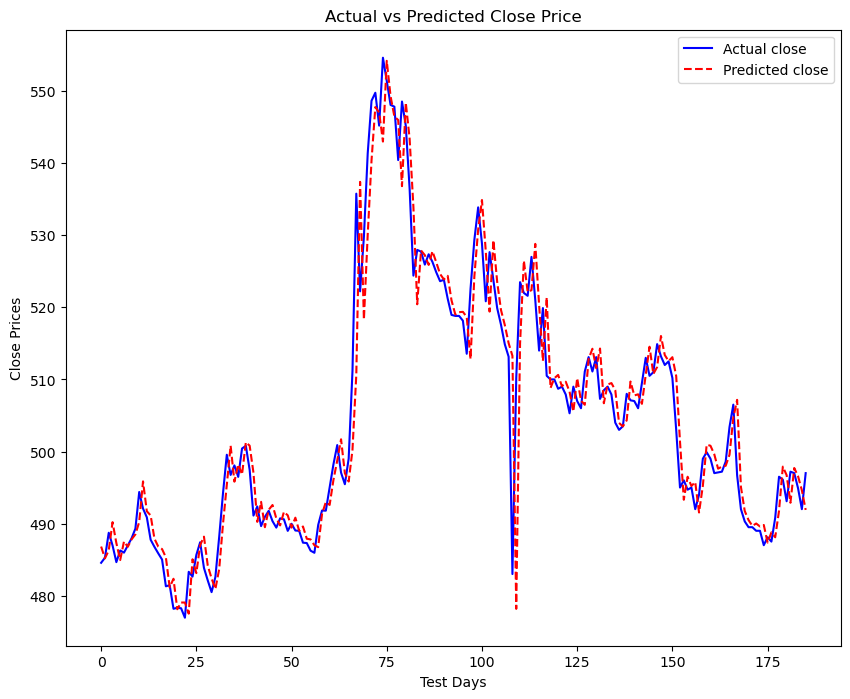

In [61]:
#actual vs predicted

plt.figure(figsize = (10,8))
plt.plot(y_test.values, label= 'Actual close', color= 'blue')
plt.plot(y_pred, label= 'Predicted close', color= 'red', linestyle = '--')
plt.title("Actual vs Predicted Close Price")
plt.xlabel("Test Days")
plt.ylabel("Close Prices")
plt.legend()
# plt.tight_layout()
plt.show()